In [41]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('dados/banking.db')

financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'CONTA', 'NOME_CONTA', 'saldo_medio']

query = f"""
SELECT 
    {', '.join(financial_indicators)} 
FROM 
    balancetes_media_ano
WHERE 
    cnpj IN (
        SELECT cnpj
        FROM balancetes_bancos_sociedades_media_ano
        GROUP BY ano, cnpj
    );"""

df = pd.read_sql_query(query, conn)

conn.close()

df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

df = df.pivot(
    index=['ano', 'cnpj', 'nome'],
    columns='conta',
    values='saldo'
).reset_index()

# Valor mínimo da conta operações de crédito
df = df[df[16000001] > 1000000]
df.dropna(subset=[39999993], inplace=True)

# Dividindo os valores pelo Ativo Total (39999993)
colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 39999993]]
for col in colunas_a_dividir:
    df[col] = df[col] / df[39999993]
df.drop(columns=[39999993, 99999995], inplace=True)


In [42]:
# Eliminando colunas esparsas

# 1. Calcular a porcentagem de zeros em cada coluna
esparsidade = df.isnull().sum() / len(df)

# 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
print(f"Colunas com > 50% de zeros: {sum(esparsidade > 0.50)}")
print(f"Colunas com > 90% de zeros: {sum(esparsidade > 0.90)}")
print(f"Colunas com > 95% de zeros: {sum(esparsidade > 0.95)}")

# 3. Definir o limiar (Recomendação: 0.90 a 0.95)
limiar_corte = 0.30

# Identificar colunas a serem removidas
colunas_para_remover = esparsidade[esparsidade > limiar_corte].index

# 4. Criar o novo dataset filtrado
df_filtrado = df.drop(columns=colunas_para_remover)

print(f"\nDimensão original: {df.shape[1]} colunas")
print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
df_filtrado.fillna(0, inplace=True)

Colunas com > 50% de zeros: 133
Colunas com > 90% de zeros: 56
Colunas com > 95% de zeros: 39

Dimensão original: 211 colunas
Dimensão após corte de esparsidade: 61 colunas


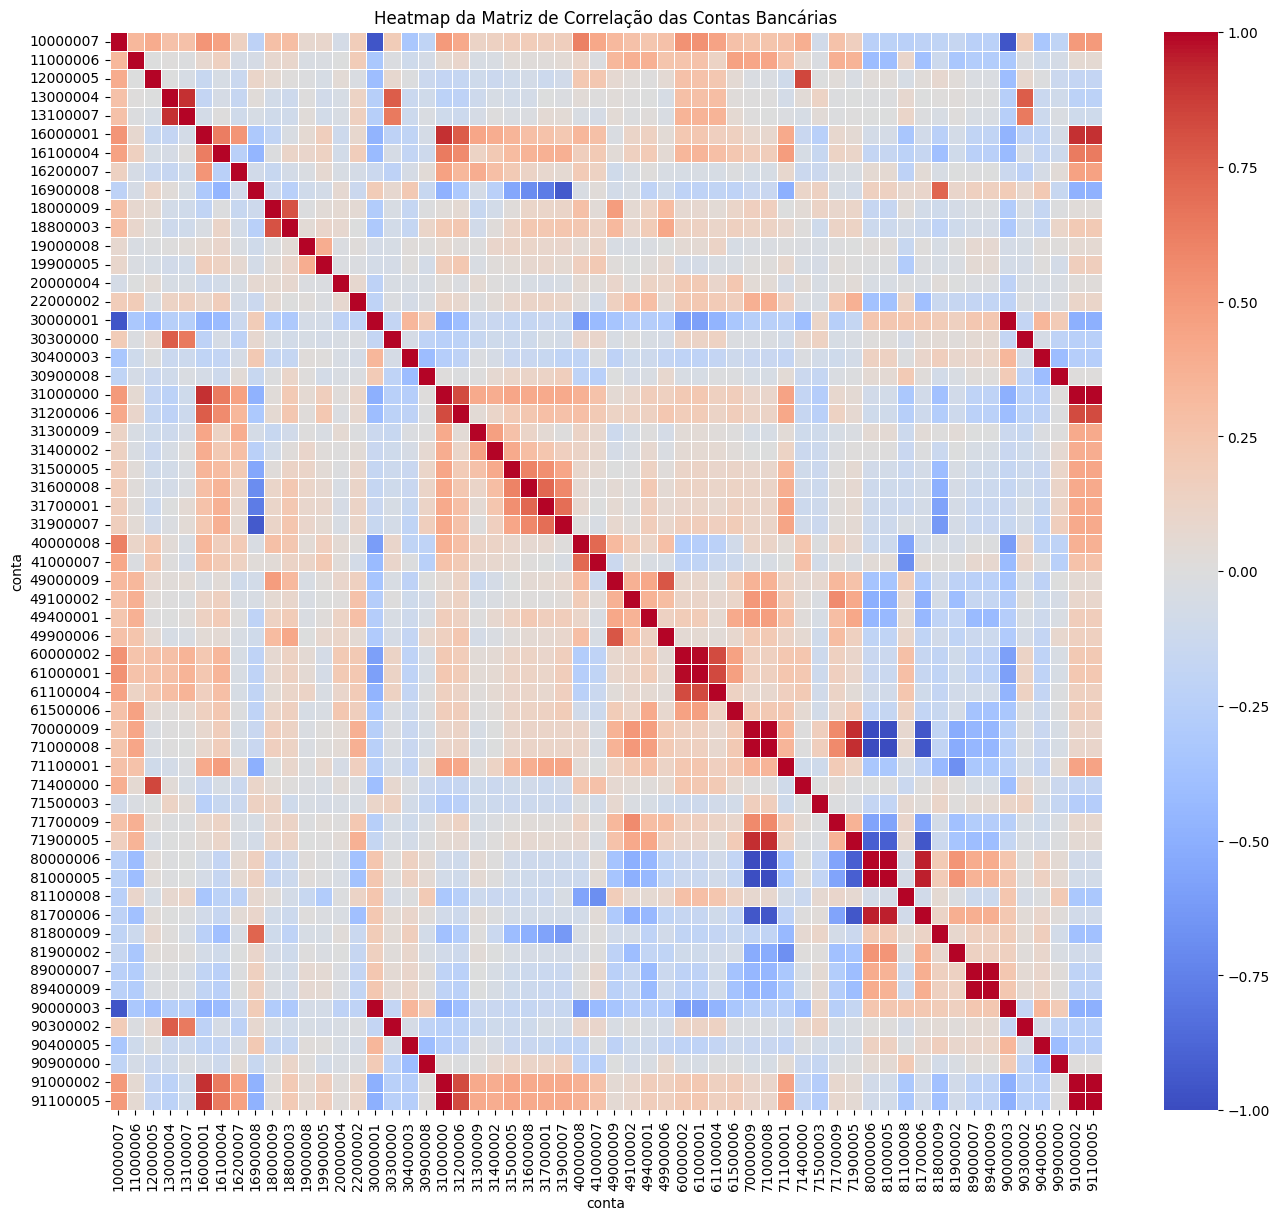

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Vamos separar apenas as colunas numéricas (features)
features = [col for col in df_filtrado.columns if col not in ['ano', 'cnpj', 'nome']] # Exclui identificadores
X = df_filtrado[features]

corr_matrix = X.corr(method='pearson')
plt.figure(figsize=(16, 14)) 

# Usar um heatmap do seaborn
# Cmap='coolwarm' é ótimo, pois destaca cores diferentes para correlação positiva e negativa
sns.heatmap(
    corr_matrix, 
    annot=False,            # Não mostrar os números (seria ilegível com 159)
    cmap='coolwarm', 
    fmt=".2f",              # Formato de duas casas decimais
    linewidths=.5,          # Linhas entre as células
    vmin=-1, vmax=1         # Definir escala de -1 a 1
)

plt.title('Heatmap da Matriz de Correlação das Contas Bancárias')
plt.show()


In [44]:
# 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
corr_matrix_abs = corr_matrix.abs()

# 2. Selecionar apenas o triângulo superior da matriz
# Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 3. Definir o Limiar de Corte (Threshold)
# 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
threshold = 0.90

# Encontrar colunas que têm correlação > threshold com qualquer outra coluna
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
print(to_drop)

# Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
X.drop(columns=to_drop, inplace=True)
features = X.columns.tolist()
# Padronizar (Média 0, Desvio Padrão 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#corr_matrix_scaled = X_scaled.corr(method='pearson')



--- Contas Redundantes a Descartar (Correlação > 0.9) ---
Número de variáveis sugeridas para remoção: 17
[13100007, 30000001, 31000000, 31900007, 61000001, 71000008, 71900005, 80000006, 81000005, 81700006, 89400009, 90000003, 90300002, 90400005, 90900000, 91000002, 91100005]


/tmp/ipykernel_1043385/931292823.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=to_drop, inplace=True)


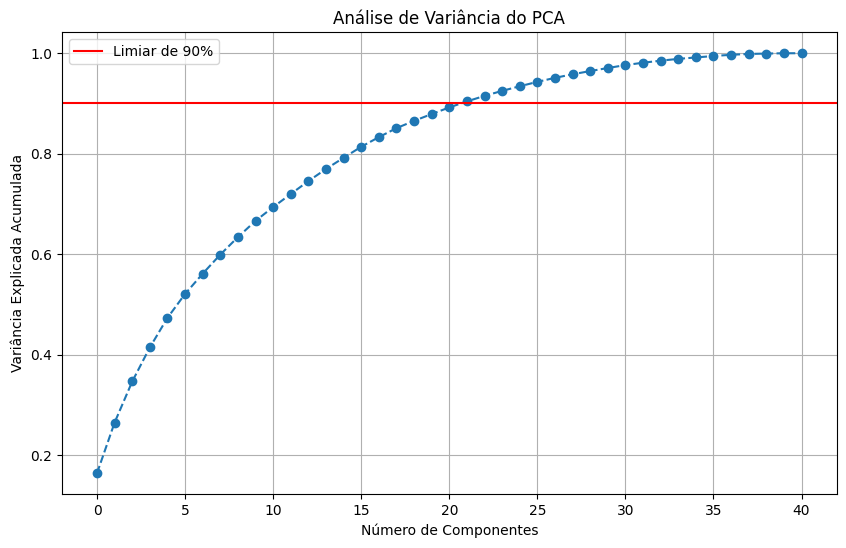

Número ideal de componentes para reter 90% da informação: 22


In [45]:
# 2. Ajustar o PCA sem limitar componentes (para análise)
pca_analise = PCA()
pca_analise.fit(X_scaled)

# Calcular a variância acumulada
variancia_acumulada = np.cumsum(pca_analise.explained_variance_ratio_)

# Plotar o gráfico para decisão visual
plt.figure(figsize=(10, 6))
plt.plot(variancia_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Variância do PCA')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='-', label='Limiar de 90%') # Linha de corte
plt.legend()
plt.show()

# Calcular matematicamente o número ideal (k) para 90% de variância
k_ideal = np.argmax(variancia_acumulada >= 0.90) + 1
print(f"Número ideal de componentes para reter 90% da informação: {k_ideal}")

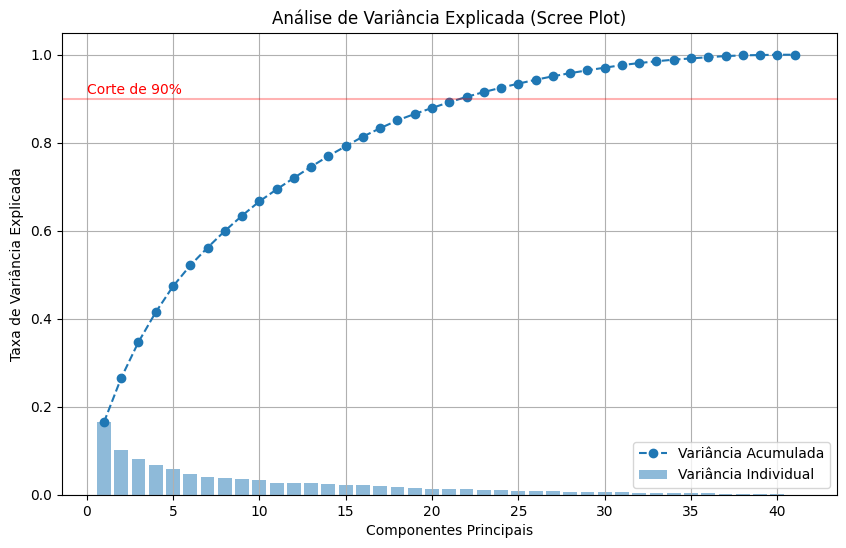

Número de componentes para explicar 90% da variância: 22


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Ajustar o PCA em todos os dados (supondo que X_scaled já é sua base normalizada)
# Se você tiver 55 variáveis, ele vai calcular 55 componentes
pca_full = PCA().fit(X_scaled)

# 2. Obter a variância explicada
# A) Individual: Quanto cada componente explica sozinho (ex: PC1 explica 40%, PC2 explica 10%...)
var_exp = pca_full.explained_variance_ratio_

# B) Acumulada: A soma progressiva (ex: PC1+PC2 explicam 50%...)
cum_var_exp = np.cumsum(var_exp)

# 3. Visualizar (O Gráfico Decisivo)
plt.figure(figsize=(10, 6))

# Plot da variância acumulada (Linha)
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o', linestyle='--', label='Variância Acumulada')

# Plot da variância individual (Barras)
plt.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.5, align='center', label='Variância Individual')

# Linhas de corte sugeridas (ex: 80% e 90%)
plt.axhline(y=0.90, color='r', linestyle='-', alpha=0.3)
plt.text(0, 0.91, 'Corte de 90%', color='r')

plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.legend(loc='best')
plt.grid(True)
plt.title('Análise de Variância Explicada (Scree Plot)')
plt.show()

# 4. Verificação Numérica
# Quantos componentes são necessários para atingir 90%?
n_components_90 = np.argmax(cum_var_exp >= 0.90) + 1
print(f"Número de componentes para explicar 90% da variância: {n_components_90}")

In [47]:
# 3. Aplicar o PCA com o número de componentes escolhido
pca_final = PCA(n_components=k_ideal)
X_pca = pca_final.fit_transform(X_scaled)

# X_pca agora é a sua nova matriz de dados para o DBSCAN!
# Ela tem o mesmo número de bancos (linhas), mas muito menos colunas.

In [48]:
# Criar um DataFrame com os pesos (Loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(k_ideal)], 
    index=features
)

# Para cada Componente Principal, ver as 5 variáveis mais influentes
for i in range(3): # Vamos olhar só os 3 primeiros componentes como exemplo
    coluna = f'PC{i+1}'
    print(f"\n--- Principais influenciadores do {coluna} ---")
    # Ordenar pelo valor absoluto do peso
    top_features = loadings[coluna].abs().sort_values(ascending=False).head(5)
    
    # Mostrar a feature e se a correlação é positiva ou negativa
    for feature, peso in top_features.items():
        sinal = "+" if loadings.loc[feature, coluna] > 0 else "-"
        print(f"{feature}: {sinal} ({loadings.loc[feature, coluna]:.4f})")


--- Principais influenciadores do PC1 ---
10000007: + (0.2600)
71100001: + (0.2575)
16900008: - (-0.2518)
16100004: + (0.2508)
31200006: + (0.2354)

--- Principais influenciadores do PC2 ---
49000009: + (0.2654)
16000001: - (-0.2452)
70000009: + (0.2234)
81100008: + (0.2202)
16200007: - (-0.2176)

--- Principais influenciadores do PC3 ---
40000008: + (0.4384)
41000007: + (0.4375)
81100008: - (-0.3537)
10000007: + (0.2891)
71400000: + (0.2662)


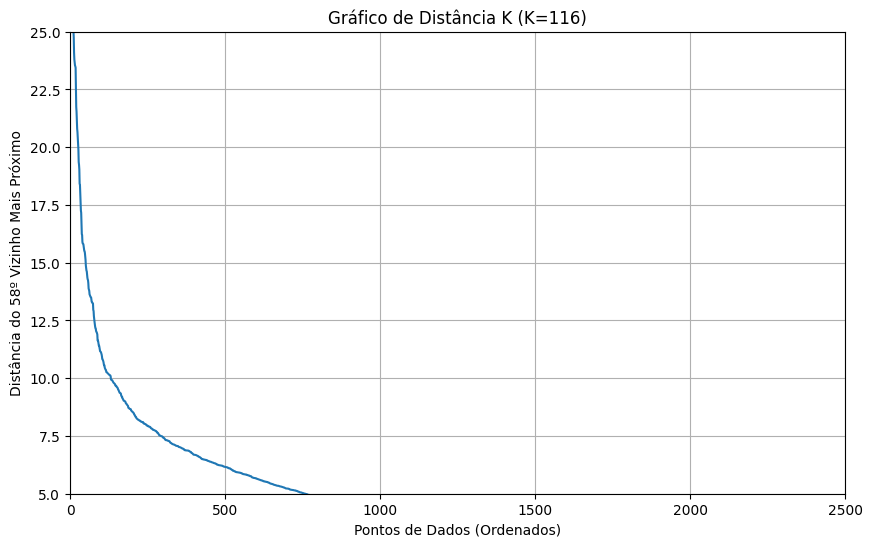

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Recalcular a distância K (Agora usando X_pca!) para achar o novo Epsilon
k = 58
neigh = NearestNeighbors(n_neighbors=2*k) # MinPts ajustado para nova dimensão
nbrs = neigh.fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distancias_ordenadas = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 6))
plt.plot(distancias_ordenadas)
plt.ylim(5, 25)
plt.xlim(0, 2500)
plt.title(f'Gráfico de Distância K (K={2*k})')
plt.xlabel('Pontos de Dados (Ordenados)')
plt.ylabel(f'Distância do {k}º Vizinho Mais Próximo')
plt.grid(True)
plt.savefig('k_distance_graph.png')


In [50]:

# Rodar DBSCAN
epsilon_escolhido = 15 # Exemplo: valor vindo do gráfico
dbscan = DBSCAN(eps=epsilon_escolhido, min_samples=2*k)
clusters = dbscan.fit_predict(X_pca)

# Salvar no DataFrame original para análise
df_filtrado['Cluster_DBSCAN'] = clusters

In [51]:
loadings.to_csv('dados/loadings.csv', index=True)